# <center> 实验3：Pandas与数据可视化实验</center>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = [
    "SimHei"
]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

### 题目1：Series创建与索引

创建一个Pandas Series，数据为 `[10, 20, 30, 40, 50]`，索引为 `[‘a’, ‘b’, ‘c’, ‘d’, ‘e’]`。
1.  通过标签索引获取值 `‘c’` 和 `‘e’` 对应的值。
2.  通过位置切片获取第2到第4个（位置从0开始）元素。
3.  通过布尔索引筛选出所有大于25的值。


In [2]:
# 创建Series
s = pd.Series([10, 20, 30, 40, 50], index=["a", "b", "c", "d", "e"])

print("s['c']:", s["c"])
print("s['e']:", s["e"])
print("s[['c', 'e']]:\n", s[["c", "e"]])

print("s[1:4]:\n", s[1:4])

print("s[s > 25]:\n", s[s > 25])

s['c']: 30
s['e']: 50
s[['c', 'e']]:
 c    30
e    50
dtype: int64
s[1:4]:
 b    20
c    30
d    40
dtype: int64
s[s > 25]:
 c    30
d    40
e    50
dtype: int64


### 题目2：Series基本运算与处理缺失值

有两个Series：
-  s1数据为 `[1, 2, 3, 4]`，索引为 `[‘a’, ‘b’, ‘c’, ‘d’]` 
-  s2数据为 `[10, 20, 30, 40]`，索引为 `[‘b’, ‘c’, ‘d’, ‘e’])`

计算两者的和。

In [3]:
s1 = pd.Series([1, 2, 3, 4], index=["a", "b", "c", "d"])

s2 = pd.Series([10, 30, 40, 50], index=["b", "c", "d", "e"])

print("s1 + s2:\n", s1 + s2)

s1 + s2:
 a     NaN
b    12.0
c    33.0
d    44.0
e     NaN
dtype: float64


### 题目3：DataFrame数据分组与聚合
给定一个DataFrame df，包含列 Category 和 Value，按 Category 分组并计算每组的平均值。

In [4]:
data = {
    "Category": ["A", "B", "C", "A", "B", "C", "A", "B", "C", "A"],
    "Value": [61, 24, 81, 70, 30, 92, 96, 84, 84, 97],
}
df = pd.DataFrame(data)
print("原始DataFrame:\n", df)

# 按Category分组并计算平均值
grouped_mean = df.groupby("Category")["Value"].mean()
print("\n按Category分组后的平均值:\n", grouped_mean)

原始DataFrame:
   Category  Value
0        A     61
1        B     24
2        C     81
3        A     70
4        B     30
5        C     92
6        A     96
7        B     84
8        C     84
9        A     97

按Category分组后的平均值:
 Category
A    81.000000
B    46.000000
C    85.666667
Name: Value, dtype: float64


### 题目4：DataFrame数据透视表
给定一个DataFrame df，包含列 Date、Category 和 Value，创建以 Date 为行、Category 为列的数据透视表，并计算 Value 的总和。

In [5]:
data = {
    "Date": ["2023-01-01", "2023-01-01", "2023-01-02", "2023-01-02"],
    "Category": ["A", "B", "A", "B"],
    "Value": [1, 2, 3, 4],
}
df = pd.DataFrame(data)
print(df)

pivot_table = df.pivot_table(
    values="Value", index="Date", columns="Category", aggfunc="sum"
)
print("\n数据透视表:\n", pivot_table)

         Date Category  Value
0  2023-01-01        A      1
1  2023-01-01        B      2
2  2023-01-02        A      3
3  2023-01-02        B      4

数据透视表:
 Category    A  B
Date            
2023-01-01  1  2
2023-01-02  3  4


### 题目5：数据分箱
给定一个DataFrame `df`
1. 将列 `Value` 分为3个等宽的区间，并添加新列 `Bin1` 表示区间。
2. 将列 `Value` 分为3个等深的区间，并添加新列 `Bin2` 表示区间。

In [6]:
data = {"Value": [61, 24, 81, 70, 30, 92, 96, 84, 97]}
df = pd.DataFrame(data)

# 1. 将列 `Value` 分为3个等宽的区间
df["Bin1"] = pd.cut(df["Value"], bins=3)

# 2. 将列 `Value` 分为3个等深的区间
df["Bin2"] = pd.qcut(df["Value"], q=3)

print(df)

   Value              Bin1            Bin2
0     61  (48.333, 72.667]  (23.999, 67.0]
1     24  (23.927, 48.333]  (23.999, 67.0]
2     81    (72.667, 97.0]  (67.0, 86.667]
3     70  (48.333, 72.667]  (67.0, 86.667]
4     30  (23.927, 48.333]  (23.999, 67.0]
5     92    (72.667, 97.0]  (86.667, 97.0]
6     96    (72.667, 97.0]  (86.667, 97.0]
7     84    (72.667, 97.0]  (67.0, 86.667]
8     97    (72.667, 97.0]  (86.667, 97.0]


### 题目6：  加载58同城房源销售数据.

In [ ]:
!pip install openpyxl

file_path = "data/58.xlsx"
df_house = pd.read_excel(file_path)
# 显示数据的前几行，以确认加载成功
df_house.head()

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]



,price,housearea,houseoriented,shishu,housefloor,housetype
0,50000,100,南,2,3,公寓
1,73513,123,南北,3,4,连排别墅
2,23434,86,北,3,5,公寓
3,45623,45,北,2,8,独立屋
4,18573,65,南,2,7,连排别墅


### 题目7： 房价分布分析 - 直方图
分析58同城平台上房产价格的分布情况，使用等宽区间划分方法将价格范围均匀分为8个区间，了解各价格区间的房源数量分布特征。

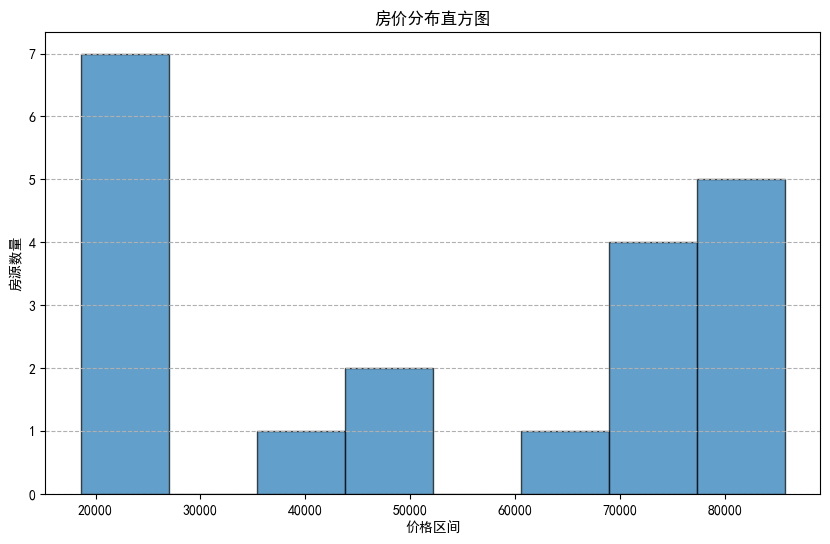

In [10]:
plt.figure(figsize=(10, 6))
# 绘制价格的直方图，分为8个区间
plt.hist(df_house["price"], bins=8, edgecolor="black", alpha=0.7)
plt.title("房价分布直方图")
plt.xlabel("价格区间")
plt.ylabel("房源数量")
plt.grid(axis="y", linestyle="--")
plt.show()

### 题目8： 户型与价格关系 - 柱状图
比较不同户型（公寓、连排别墅、独立屋）的平均价格,绘制各户型的平均价格柱状图

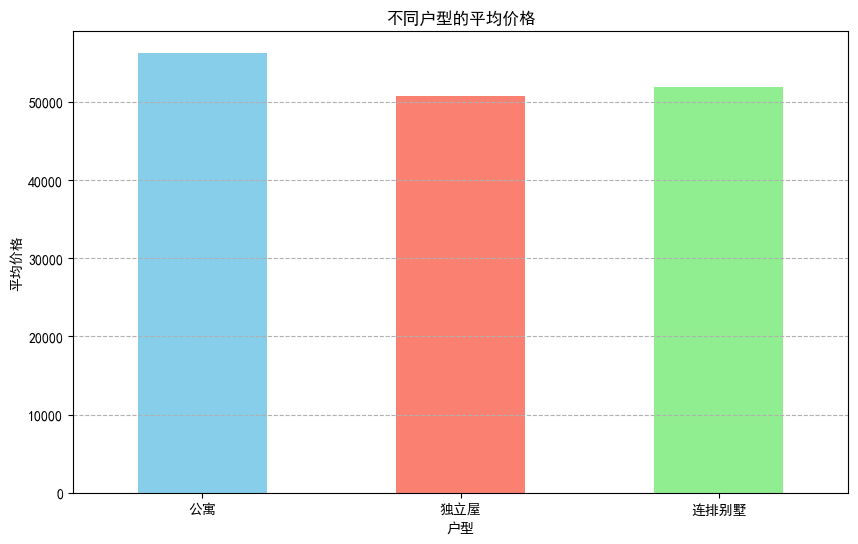

In [ ]:
avg_price_by_type = df_house.groupby("housetype")["price"].mean()

plt.figure(figsize=(10, 6))
avg_price_by_type.plot(kind="bar", color=["skyblue", "salmon", "lightgreen"])
plt.title("不同户型的平均价格")
plt.xlabel("户型")
plt.ylabel("平均价格")
plt.xticks(rotation=0)  # 让x轴标签水平显示
plt.grid(axis="y", linestyle="--")
plt.show()

### 题目9： 房屋面积与价格关系 - 散点图
探索房屋面积与价格的相关关系，绘制面积-价格的散点图

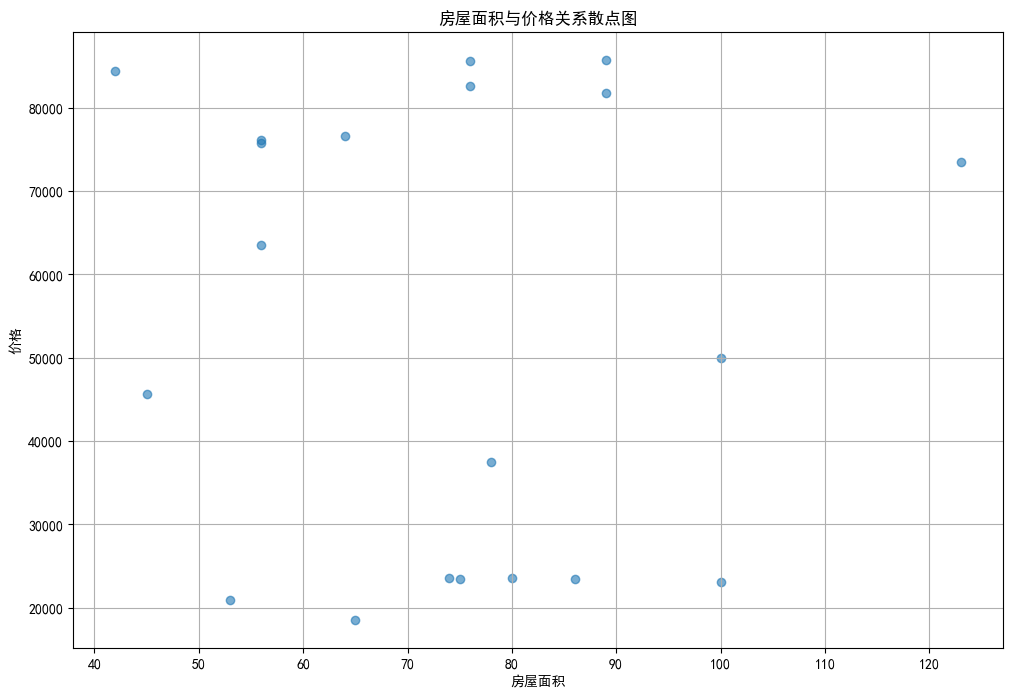

In [12]:
plt.figure(figsize=(12, 8))
plt.scatter(df_house["housearea"], df_house["price"], alpha=0.6)
plt.title("房屋面积与价格关系散点图")
plt.xlabel("房屋面积")
plt.ylabel("价格")
plt.grid(True)
plt.show()

### 题目10： 楼层分布分析 - 曲线图
分析楼层高度与房价的关系趋势，绘制楼层与平均价格的折线图

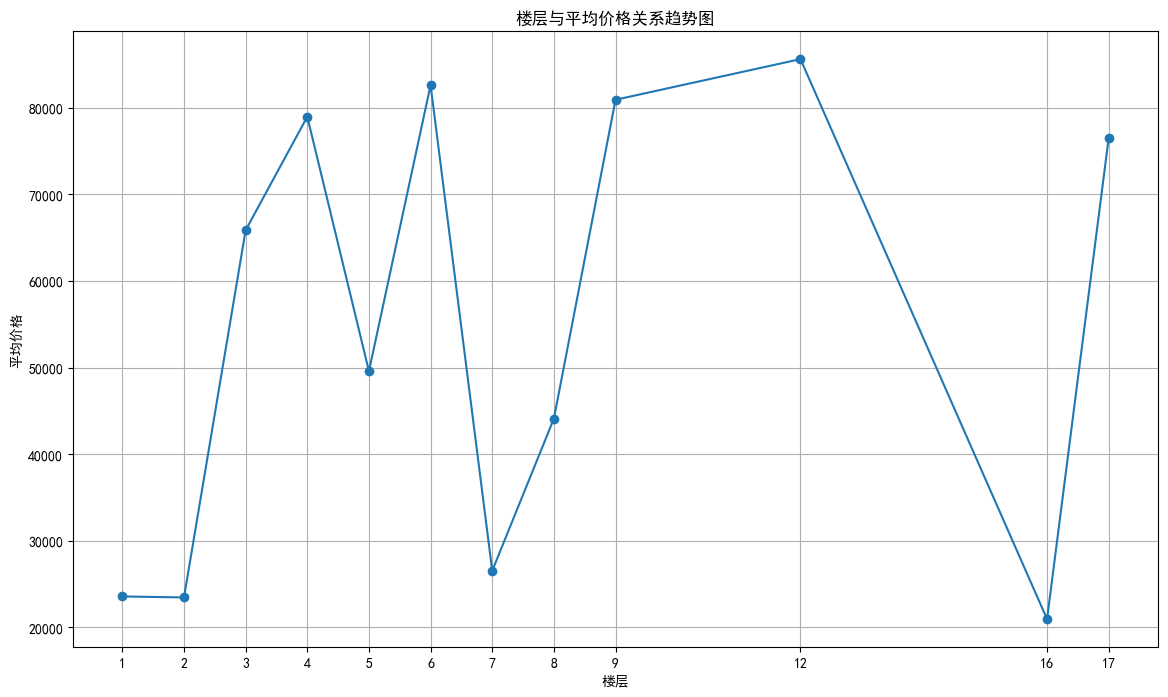

In [13]:
avg_price_by_floor = df_house.groupby("housefloor")["price"].mean().sort_index()

# 绘制折线图
plt.figure(figsize=(14, 8))
avg_price_by_floor.plot(kind="line", marker="o", linestyle="-")
plt.title("楼层与平均价格关系趋势图")
plt.xlabel("楼层")
plt.ylabel("平均价格")
plt.xticks(avg_price_by_floor.index)  # 确保所有楼层都作为刻度显示
plt.grid(True)
plt.show()